In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from banco import conectar

In [2]:
#Configurações visuais para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

conn = conectar()
print("Deu certo!")

Deu certo!


,tipo_pagamento,valor_medio
0,DIÁRIAS,2078.28
1,PASSAGEM,1878.34
2,Serviço correlato: seguro,447.51
3,RESTITUIÇÃO,245.70


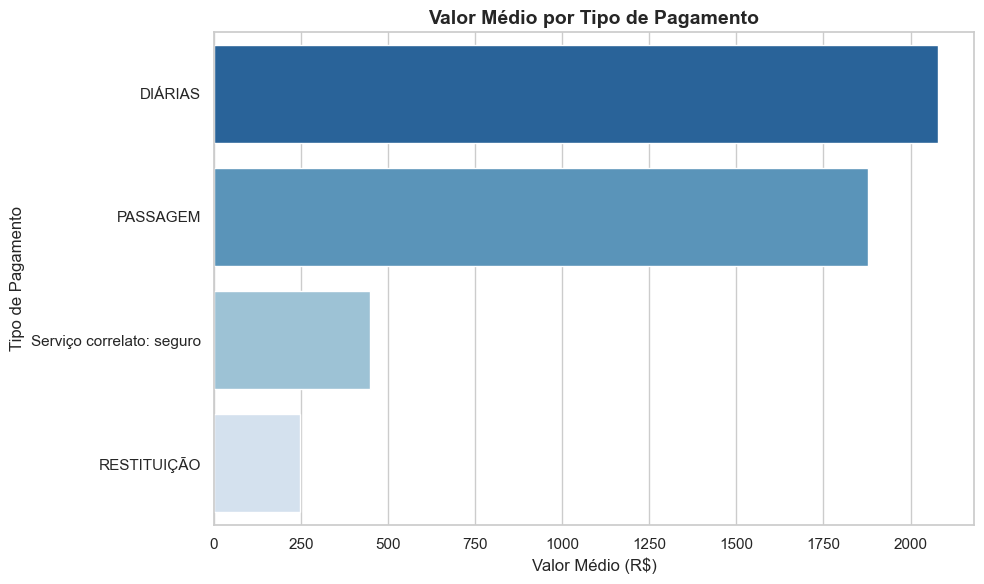

In [3]:
#Respondendo perguntas diretas da camada Silver
##Pergunta 4: Qual o tipo de pagamento com maior valor médio?
query_q4 = '''SELECT tipo_pagamento, ROUND(AVG(valor), 2) AS valor_medio
FROM silver_pagamento
GROUP BY tipo_pagamento
ORDER BY valor_medio DESC;
'''
df_q4 = pd.read_sql(query_q4, conn)
display(df_q4)

plt.figure()
sns.barplot(data=df_q4, x='valor_medio', y='tipo_pagamento', palette='Blues_r', hue='tipo_pagamento')
plt.title('Valor Médio por Tipo de Pagamento', fontweight='bold')
plt.xlabel('Valor Médio (R$)')
plt.ylabel('Tipo de Pagamento')
plt.tight_layout()
plt.show()
plt.close()

,meio_transporte,total_trechos
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659
5,Fluvial,8429
6,Ferroviário,874
7,Marítimo,481


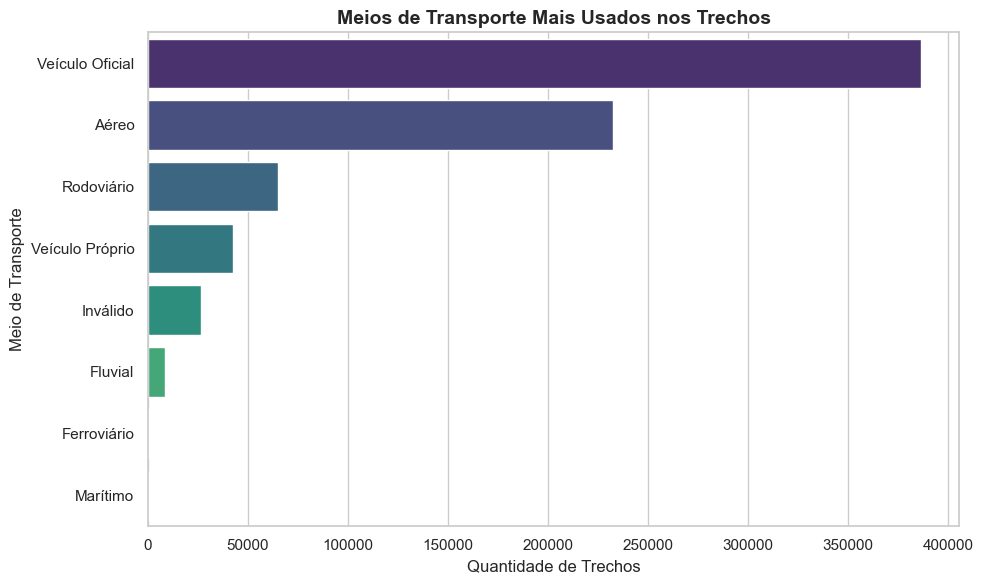

In [4]:
##Pergunta 5: Qual o meio de transporte mais usado nos trechos?
query_q5 = '''
SELECT meio_transporte, COUNT(*) AS total_trechos
FROM silver_trecho
WHERE meio_transporte IS NOT NULL AND meio_transporte != ''
GROUP BY meio_transporte
ORDER BY total_trechos DESC;
'''
df_q5 = pd.read_sql(query_q5, conn)
display(df_q5)

plt.figure()
sns.barplot(data=df_q5, x='total_trechos', y='meio_transporte', palette='viridis')
plt.title('Meios de Transporte Mais Usados nos Trechos', fontweight='bold')
plt.xlabel('Quantidade de Trechos')
plt.ylabel('Meio de Transporte')
plt.tight_layout()
plt.show()
plt.close()


,destino_uf,total_trechos
0,São Paulo,82722
1,Distrito Federal,79962
2,Minas Gerais,50965
3,Rio de Janeiro,44197
4,Paraná,42603
5,Pará,40044
6,Rio Grande do Sul,38684
7,Mato Grosso do Sul,30516
8,Bahia,28375
9,Pernambuco,28372


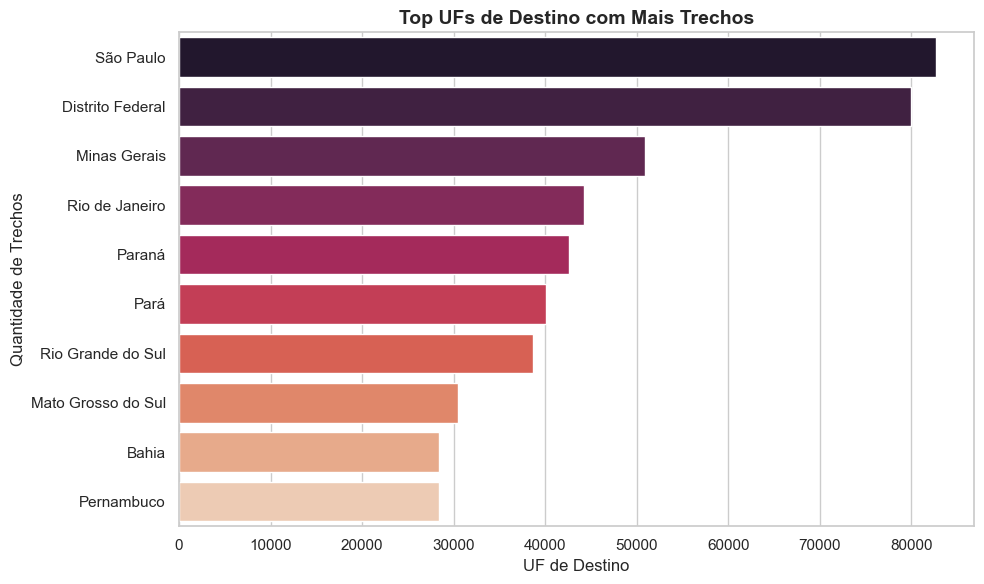

In [5]:
##Pergunta 6: Qual o meio de transporte mais usado nos trechos?
query_q6 = """
SELECT destino_uf, COUNT(*) AS total_trechos
FROM silver_trecho
WHERE destino_uf IS NOT NULL AND destino_uf NOT IN ('', 'IGNORADO', 'Sem Informação')
GROUP BY destino_uf
ORDER BY total_trechos DESC
LIMIT 10;
"""
df_q6 = pd.read_sql(query_q6, conn)
display(df_q6)

plt.figure()
sns.barplot(data=df_q6, x='total_trechos', y='destino_uf', palette='rocket')
plt.title('Top UFs de Destino com Mais Trechos', fontweight='bold')
plt.xlabel('UF de Destino')
plt.ylabel('Quantidade de Trechos')
plt.tight_layout()
plt.show()
plt.close()

Com 3 perguntas respondidas na camada Silver, como solicitado, aqui seguirei criando a View Gold e fazendo agregações.

In [6]:
#Criando a View Gold e agregando Viagens e Pagamentos
cursor = conn.cursor()

query_view = '''
CREATE OR REPLACE VIEW gold_resumo_orgaos AS
SELECT 
    v.nome_orgao_superior,
    COUNT(DISTINCT v.id_viagem) AS qtd_viagens,
    SUM(v.valor_total) AS custo_total_declarado,
    SUM(p.valor) AS valor_total_pago
FROM silver_viagem v
INNER JOIN silver_pagamento p ON v.id_viagem = p.id_viagem
GROUP BY v.nome_orgao_superior;
'''
cursor.execute(query_view)

#Criação da TABELA Gold física
query_table = """
DROP TABLE IF EXISTS gold_tabela_resumo_orgaos;
CREATE TABLE gold_tabela_resumo_orgaos AS 
SELECT * FROM gold_resumo_orgaos;
"""
cursor.execute(query_table)
conn.commit()
cursor.close()
print("Camada Gold deu boa")

Camada Gold deu boa


Com a Camada Gold criada, irei responder as perguntas com ela

,nome_orgao_superior,custo_total_declarado
0,Ministério da Justiça e Segurança Pública,7.543771e+09
1,Ministério da Defesa,3.425856e+08
2,Ministério da Educação,2.746155e+08
3,Ministério da Previdência Social,1.932517e+08
4,Ministério do Meio Ambiente e Mudança do Clima,1.611365e+08


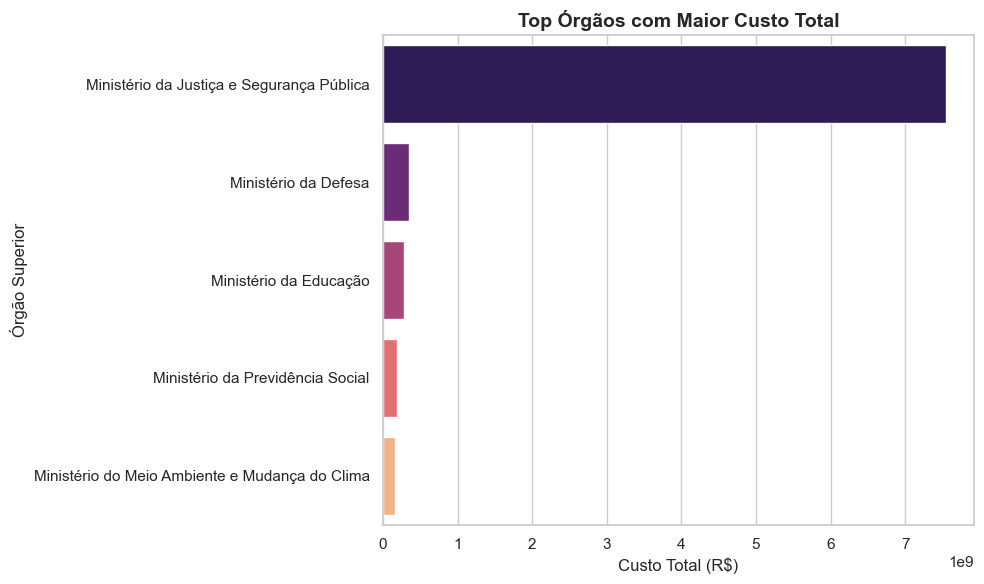

In [7]:
##Pergunta 1: Os 5 órgãos com maior custo total?
query_q1 = '''
SELECT nome_orgao_superior, custo_total_declarado
FROM gold_tabela_resumo_orgaos
ORDER BY custo_total_declarado DESC
LIMIT 5;
'''
df_q1 = pd.read_sql(query_q1, conn)
display(df_q1)

plt.figure()
sns.barplot(data=df_q1, x='custo_total_declarado', y='nome_orgao_superior', palette='magma')
plt.title('Top Órgãos com Maior Custo Total', fontweight='bold')
plt.xlabel('Custo Total (R$)')
plt.ylabel('Órgão Superior')
plt.tight_layout()
plt.show()
plt.close()

In [8]:
##Pergunta 7: Qual órgão pagou mais no total?
query_q7 = '''
SELECT nome_orgao_superior, valor_total_pago
FROM gold_tabela_resumo_orgaos
ORDER BY valor_total_pago DESC
LIMIT 1;
'''
df_q7 = pd.read_sql(query_q7, conn)
#Por se tratar de apenas a resposta de qual órgão pagou mais no total, optei por não plotar gráfico aqui, mas apenas manter a resposta.
print("Resposta da Pergunta 7:")
display(df_q7)


Resposta da Pergunta 7:


,nome_orgao_superior,valor_total_pago
0,Ministério da Justiça e Segurança Pública,4.888311e+08


,destino_principal,custo_medio
0,Guiyang/China,112870.41
1,Nova Maringá/MT,70621.26
2,Lusaca/Zâmbia,62803.64


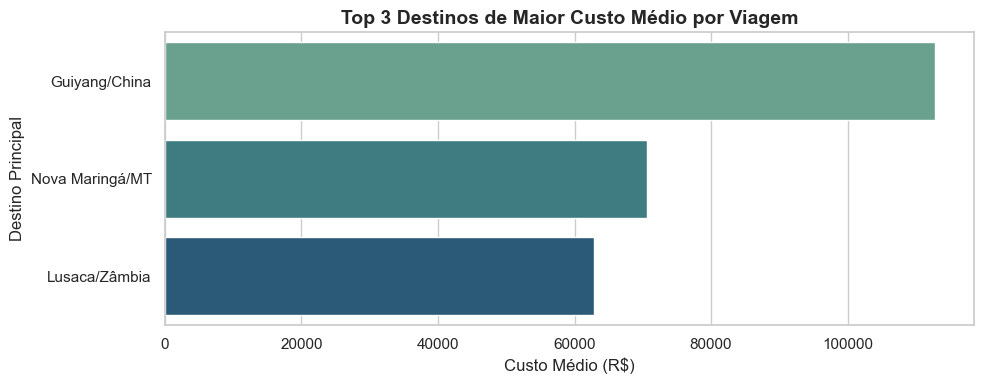

In [9]:
##Pergunta 2: Os 3 destinos com maior custo médio por viagem?
query_q2 = '''
SELECT 
    SPLIT_PART(destinos, ',', 1) AS destino_principal, -- Pega apenas a primeira cidade antes da vírgula
    ROUND(AVG(valor_total), 2) AS custo_medio
FROM silver_viagem
WHERE destinos IS NOT NULL AND destinos != ''
GROUP BY SPLIT_PART(destinos, ',', 1)
ORDER BY custo_medio DESC
LIMIT 3;
'''
df_q2 = pd.read_sql(query_q2, conn)
display(df_q2)

plt.figure(figsize=(10, 4))
sns.barplot(data=df_q2, x='custo_medio', y='destino_principal', palette='crest')
plt.title('Top 3 Destinos de Maior Custo Médio por Viagem', fontweight='bold')
plt.xlabel('Custo Médio (R$)')
plt.ylabel('Destino Principal')
plt.tight_layout()
plt.show()
plt.close()

In [10]:
##Pergunta 3: A viagem de maior duração e seu custo total?
#Por se tratar de apenas a resposta de qual órgão pagou mais no total, optei por não plotar gráfico aqui, mas apenas manter a resposta.
query_q3 = '''
SELECT id_viagem, destinos, duracao_dias, valor_total
FROM silver_viagem
WHERE duracao_dias IS NOT NULL
ORDER BY duracao_dias DESC
LIMIT 1;
'''
#Novamente, por se tratar de apenas a resposta de qual órgão pagou mais no total, optei por não plotar gráfico aqui, mas apenas manter a resposta.
df_q3 = pd.read_sql(query_q3, conn)
print("\nA viagem de maior duração e seu custo total:")
display(df_q3)


A viagem de maior duração e seu custo total:


,id_viagem,destinos,duracao_dias,valor_total
0,0000000000020699856,Mogi Mirim/SP,383,0.0


In [11]:
#Fechando conexão com o banco
conn.close()
print('Fechou a conexão!')

Fechou a conexão!
